<a href="https://colab.research.google.com/github/MohammadRezaNamvarNejad/ABSA-LLM/blob/main/Qwen2_5_7B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U transformers accelerate bitsandbytes
!pip install -q sentence-transformers faiss-cpu lxml pandas seaborn matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 98.0 MB/s eta 0:00:00


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"

print("Downloading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

print("Downloading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map={"": 0}
)
# inference helper (updated settings)
def get_qwen_response(prompt):
    # no system role; instructions live in user message
    messages = [
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # deterministic settings for eval
    outputs = model.generate(
        **inputs,
        max_new_tokens=5,
        temperature=0.0,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, outputs)]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response.strip()

print("Model loaded and ready.")

در حال دانلود توکنایزر...


config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

در حال دانلود و بارگذاری مدل...


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

مدل با موفقیت بارگذاری و آماده تست شد! 🎉


In [4]:
import xml.etree.ElementTree as ET
import random

def load_absa_xml(file_path):
    """
    Parse SemEval XML into a list of dicts.
    """
    tree = ET.parse(file_path)
    root = tree.getroot()

    data_list = []

    # walk all sentences in the XML
    for sentence in root.iter('sentence'):
        text_node = sentence.find('text')
        if text_node is None:
            continue
        text = text_node.text

        # read Opinion nodes for target + polarity
        opinions = sentence.find('Opinions')
        if opinions is not None:
            for opinion in opinions.findall('Opinion'):
                target = opinion.get('target')
                polarity = opinion.get('polarity')

                # ABSA: skip NULL targets (restaurant-level)
                if target and target != "NULL" and polarity:
                    data_list.append({
                        'text': text,
                        'aspect': target,
                        'polarity': polarity
                    })

    return data_list

# XML filename in the working directory / Colab
xml_file_path = 'ABSA16_Restaurants_Train_SB1_v2.xml'

print("Reading dataset XML...")
# dataset feeds the FAISS cell below
dataset = load_absa_xml(xml_file_path)
print(f"Parsed {len(dataset)} aspect–sentiment pairs.")

# -------------------------------------------------------------
# build test_sample for the eval cell:
# -------------------------------------------------------------
# if you have a separate test XML, load it here:
# test_sample = load_absa_xml('ABSA16_Restaurants_Test.xml')

# otherwise hold out rows from train:
# e.g. 200 random rows for evaluation
random.seed(42)  # reproducible holdout
test_sample = random.sample(dataset, 200)

print(f"Held out {len(test_sample)} samples for evaluation.")

در حال خواندن فایل XML دیتاست...
تعداد 1880 جفت (جنبه-احساس) با موفقیت استخراج شد.
تعداد نمونه‌های آماده شده برای ارزیابی مدل (Test Sample): 200


In [5]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss

print("Loading embedding model...")
embedder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# embed full dataset as the knowledge base
kb_texts = [item['text'] for item in dataset]
print("Encoding knowledge base...")
kb_embeddings = embedder.encode(kb_texts, convert_to_tensor=False).astype(np.float32)

# FAISS index (inner product ~ cosine on normalized vectors)
faiss.normalize_L2(kb_embeddings)
dimension = kb_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(kb_embeddings)

def retrieve_similar_examples(query_text, k=3):
    """Retrieve k similar examples via FAISS."""
    query_emb = embedder.encode([query_text]).astype(np.float32)
    faiss.normalize_L2(query_emb)

    # fetch k+1 to skip the query itself when it is in the index
    distances, indices = index.search(query_emb, k + 1)

    examples = []
    for idx in indices[0]:
        if dataset[idx]['text'] != query_text:  # avoid retrieving the query
            examples.append(dataset[idx])
        if len(examples) == k:
            break

    return examples

در حال بارگذاری مدل Embedding...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

در حال ساخت بردارهای پایگاه دانش...


In [6]:
from tqdm.notebook import tqdm

def clean_prediction(pred):
    """Normalize model output to a single label."""
    pred = pred.lower().strip()
    if 'positive' in pred: return 'positive'
    if 'negative' in pred: return 'negative'
    if 'neutral' in pred: return 'neutral'
    return 'unknown'

results = {'Zero-shot': [], 'One-shot': [], 'RAG': [], 'True_Labels': []}

# hard-coded base instruction
base_instruction = """Task: Aspect-Based Sentiment Analysis (ABSA) on Restaurant Reviews.
Classify the sentiment polarity of the target aspect into exactly one of these labels: positive, negative, or neutral."""

print("Running unified benchmark eval...")
for item in tqdm(test_sample):
    text = item['text']
    aspect = item['aspect']
    true_label = item['polarity']
    results['True_Labels'].append(true_label)

    # -----------------------------------------------------
    # 1. Zero-shot
    # -----------------------------------------------------
    prompt_zero = f"""{base_instruction}
Sentence: "{text}"
Target Aspect: "{aspect}"
Output ONLY the final sentiment label in lowercase."""

    pred_zero = clean_prediction(get_qwen_response(prompt_zero))
    results['Zero-shot'].append(pred_zero)

    # -----------------------------------------------------
    # 2. One-shot (Fixed Hardcoded Example)
    # -----------------------------------------------------
    prompt_one = f"""{base_instruction}

Example:
Sentence: "The food was absolutely delicious, but the service was terrible."
Target Aspect: "food"
Sentiment: positive

Now classify the following:
Sentence: "{text}"
Target Aspect: "{aspect}"
Sentiment:"""

    pred_one = clean_prediction(get_qwen_response(prompt_one))
    results['One-shot'].append(pred_one)

    # -----------------------------------------------------
    # 3. RAG / 3-Shot (Dynamic FAISS Retrieval)
    # -----------------------------------------------------
    similar_docs = retrieve_similar_examples(text, k=3)

    rag_examples_str = ""
    for idx, doc in enumerate(similar_docs):
        rag_examples_str += f'Sentence: "{doc["text"]}" | Target Aspect: "{doc["aspect"]}" -> Sentiment: {doc["polarity"]}\n'

    prompt_rag = f"""{base_instruction}

Here are some reference examples:
{rag_examples_str.strip()}

Now classify the following:
Sentence: "{text}"
Target Aspect: "{aspect}"
Sentiment:"""

    pred_rag = clean_prediction(get_qwen_response(prompt_rag))
    results['RAG'].append(pred_rag)

print("Eval finished.")

شروع ارزیابی مدل با استاندارد یکپارچه...


  0%|          | 0/200 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=5) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=5) and `max_length`(=32768) se

ارزیابی استاندارد به پایان رسید!


در حال محاسبه متریک‌های ارزیابی...
[Zero-shot] -> Accuracy: 90.50% | Macro F1: 75.52%
[One-shot] -> Accuracy: 66.00% | Macro F1: 66.40%
[RAG] -> Accuracy: 73.00% | Macro F1: 68.99%


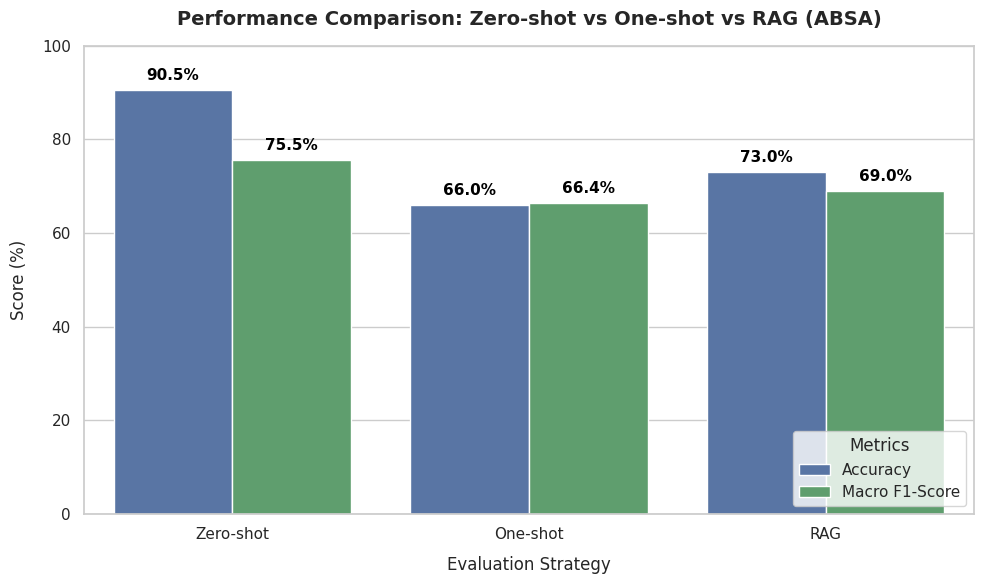

In [9]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# plot style
sns.set_theme(style="whitegrid")
print("Computing metrics...")

true_labels = results['True_Labels']
methods = ['Zero-shot', 'One-shot', 'RAG']

metrics_data = []
labels_list = ['positive', 'negative', 'neutral']

for method in methods:
    predictions = results[method]

    # accuracy + macro F1
    acc = accuracy_score(true_labels, predictions) * 100
    f1 = f1_score(true_labels, predictions, average='macro', labels=labels_list) * 100

    metrics_data.append({'Method': method, 'Metric': 'Accuracy', 'Score': acc})
    metrics_data.append({'Method': method, 'Metric': 'Macro F1-Score', 'Score': f1})

    print(f"[{method}] -> Accuracy: {acc:.2f}% | Macro F1: {f1:.2f}%")

df_metrics = pd.DataFrame(metrics_data)

# plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_metrics,
    x='Method',
    y='Score',
    hue='Metric',
    palette=['#4C72B0', '#55A868']
)

plt.title('Performance Comparison: Zero-shot vs One-shot vs RAG (ABSA)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Evaluation Strategy', fontsize=12, labelpad=10)
plt.ylabel('Score (%)', fontsize=12, labelpad=10)
plt.ylim(0, 100)
plt.legend(title='Metrics', fontsize=11, title_fontsize=12, loc='lower right')

# bar labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

در حال محاسبه دقت (Accuracy)...
[Zero-shot] -> Accuracy: 90.50%
[One-shot] -> Accuracy: 66.00%
[RAG] -> Accuracy: 73.00%


/tmp/ipykernel_964/3345598487.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


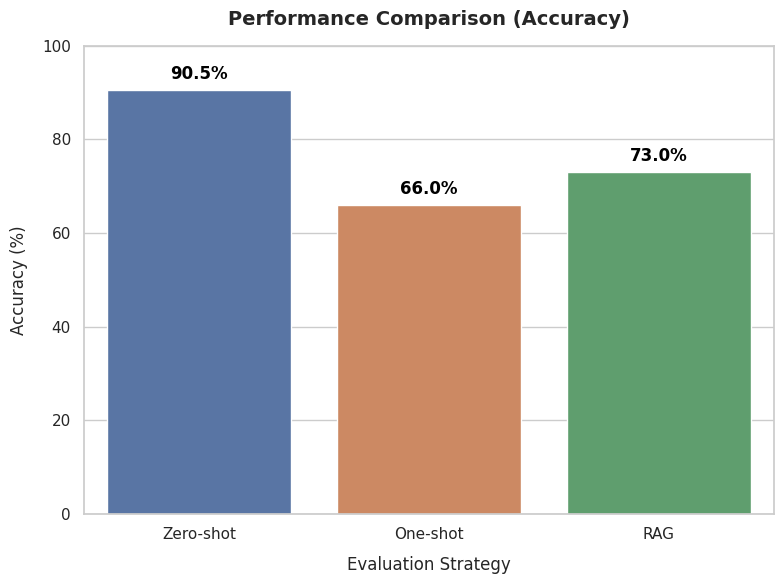

In [10]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# plot style
sns.set_theme(style="whitegrid")
print("Computing accuracy...")

true_labels = results['True_Labels']
methods = ['Zero-shot', 'One-shot', 'RAG']
accuracies = []

# per-method accuracy
for method in methods:
    predictions = results[method]
    acc = accuracy_score(true_labels, predictions) * 100
    accuracies.append(acc)
    print(f"[{method}] -> Accuracy: {acc:.2f}%")

# DataFrame for plotting
df_metrics = pd.DataFrame({
    'Method': methods,
    'Accuracy': accuracies
})

# three-bar chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=df_metrics,
    x='Method',
    y='Accuracy',
    palette=['#4C72B0', '#DD8452', '#55A868']  # one color per method
)

# chart cosmetics
plt.title('Performance Comparison (Accuracy)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Evaluation Strategy', fontsize=12, labelpad=10)
plt.ylabel('Accuracy (%)', fontsize=12, labelpad=10)
plt.ylim(0, 100)

# exact percent on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()